Same analysis but for 3 **V1 (VISp)** containers. (`511507650`, `511509529`,
`511510650`)

Download the data

In [49]:
# !python scripts/download_container.py --containers 511507650 511509529 511510650 --out-dir ../data

---

In [50]:
%load_ext autoreload
%autoreload 2

from utils import *
plt.rcParams['figure.dpi'] = 100

# Load all V1 containers
data_list, cids = load_containers("data")
total_cells = sum(len(d["matched_cell_ids"]) for d in data_list)
print(f"Containers: {cids}")
print(f"Total cells pooled: {total_cells}")
for i, d in enumerate(data_list):
    print(f"  container {cids[i]}: {len(d['matched_cell_ids'])} cells")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Containers: [511507650, 511509529, 511510650]
Total cells pooled: 246
  container 511507650: 63 cells
  container 511509529: 116 cells
  container 511510650: 67 cells


# 1 Binary Modulation — V1 pooled population

In [51]:
# Run per container, then pool all per-cell results
all_bm = [run_binary_modulation_analysis(d, RESPONSE_WINDOWS) for d in data_list]

# Print per-container summary
for i, (bm, cid) in enumerate(zip(all_bm, cids)):
    summary = summarize_binary_modulation_runs(bm)
    print(f"\n--- Container {cid} ({summary['n_trials'].iloc[0]} trials DG) ---")
    print(summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]])

# Pool across containers
modulation_results = pool_binary_modulation(all_bm)
print(f"\nPooled: modulation_results ready for {list(modulation_results.keys())}")
modulated_mask = {stim: modulation_results[stim].modulated_mask for stim in STIMULI}
print(f"Total pooled cells: {len(modulated_mask['drifting_gratings'])})")


--- Container 511507650 (598 trials DG) ---
            stimulus  n_trials  n_running  n_still  n_ignored
0  drifting_gratings       598         20       29        549
1    static_gratings      5804       5611       22        171
2     natural_scenes      5900       5332      144        424
3        spontaneous      1184        968       23        193

--- Container 511509529 (598 trials DG) ---
            stimulus  n_trials  n_running  n_still  n_ignored
0  drifting_gratings       598        169      337         92
1    static_gratings      5804       1769     3742        293
2     natural_scenes      5900       2278     3352        270
3        spontaneous       593        252      298         43

--- Container 511510650 (598 trials DG) ---
            stimulus  n_trials  n_running  n_still  n_ignored
0  drifting_gratings       598         35      489         74
1    static_gratings      5806        215     5220        371
2     natural_scenes      5900        181     5128        5

/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


DG: 46/246 modulated
SG: 123/246 modulated
NS: 159/246 modulated
Spont: 8/246 modulated


/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:1699: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  def plot_monotonicity_stacked_bar(tunings: dict[str, SpeedTuning],


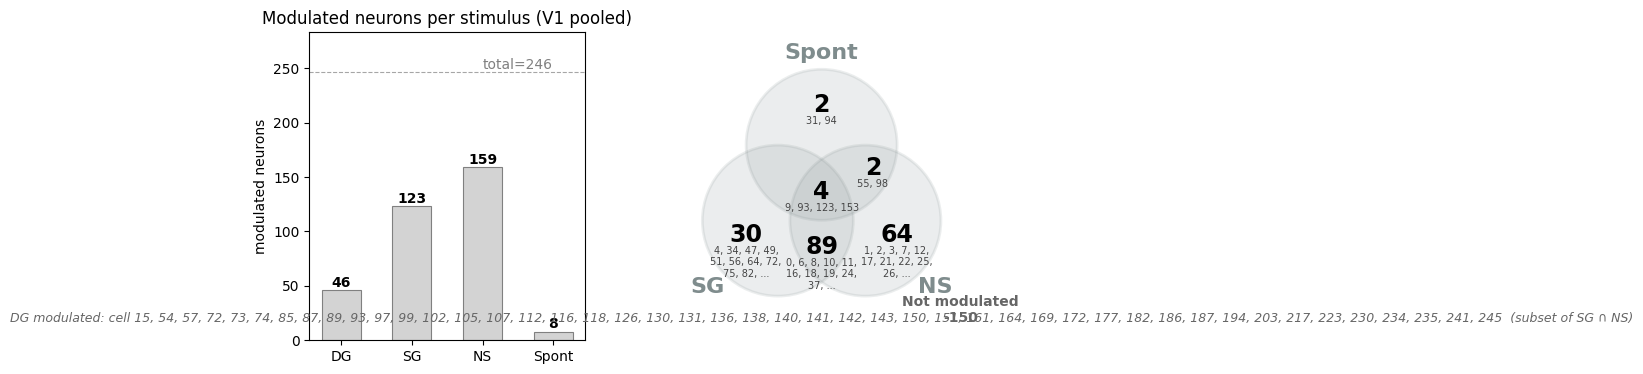

In [52]:
# Modulated neuron counts per stimulus
for stim in STIMULI:
    n_mod = int(modulated_mask[stim].sum())
    n_tot = len(modulated_mask[stim])
    print(f"{stim_to_short(stim)}: {n_mod}/{n_tot} modulated")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={'width_ratios': [1, 1.3]})
plot_modulated_counts(modulated_mask, total_cells=total_cells, ax=ax1)
ax1.set_title('Modulated neurons per stimulus (V1 pooled)')
plot_modulated_venn(modulated_mask, ax=ax2)
plt.savefig("doc/figures/V1/V1_modulated_neurons_counts.png")
plt.show()

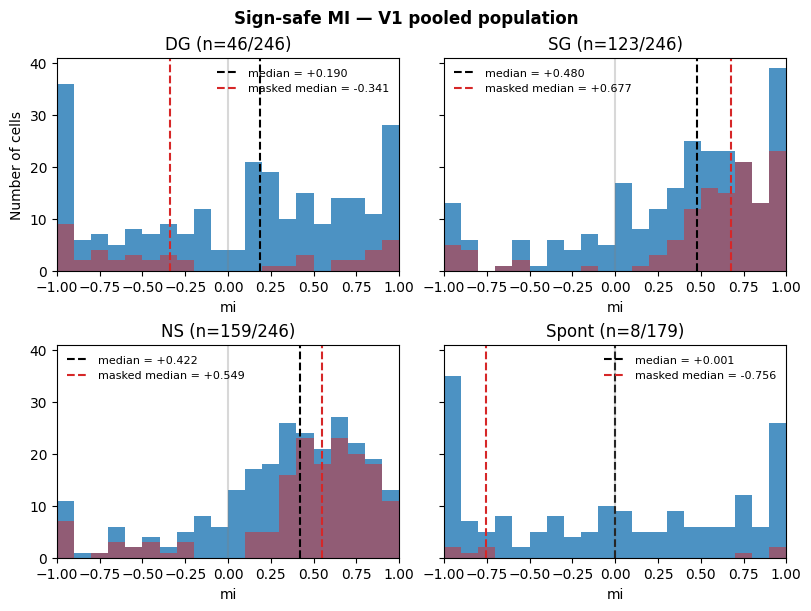

In [53]:
# Sign-safe MI distributions
fig, axes = plot_metric_comparison(modulation_results, metric="mi", neurons_mask=modulated_mask)
fig.suptitle("Sign-safe MI — V1 pooled population", fontweight='bold')
plt.savefig("doc/figures/V1/V1_MI_histogram_populations.png")
plt.show()

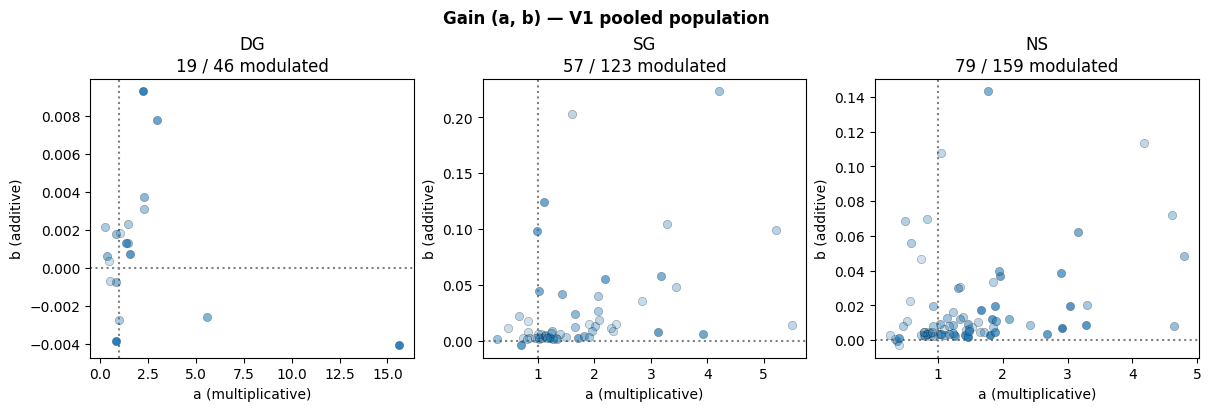

In [54]:
# Gain scatter — V1 pooled
fig = plot_gain_scatter(modulation_results, r2_threshold=0.2)
fig.suptitle("Gain (a, b) — V1 pooled population", fontweight='bold')
plt.savefig("doc/figures/V1/V1_gain_scatter.png")
plt.show()

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:3344: RuntimeWarning: Mean of empty slice
  


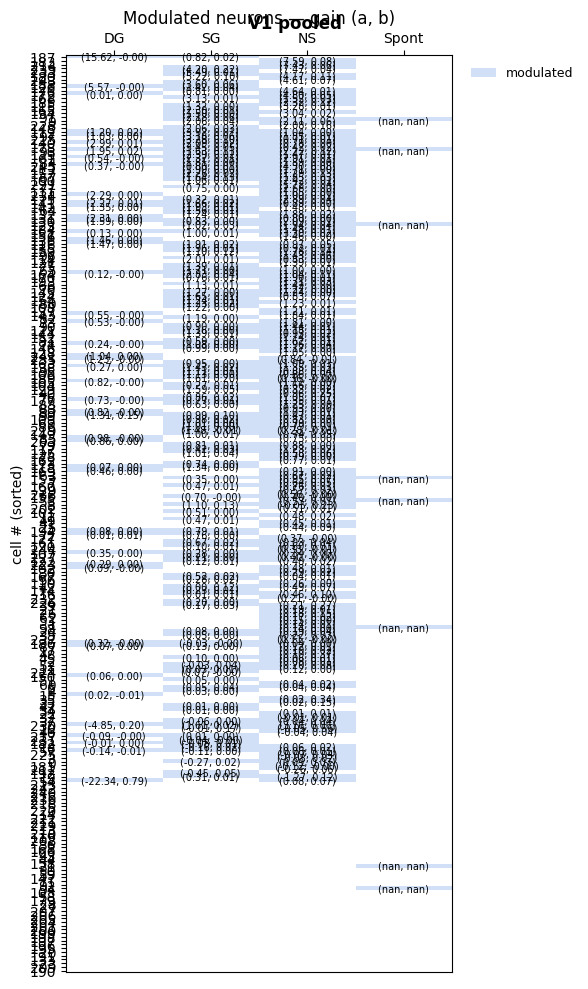

In [55]:
# Modulation grid — V1 pooled
fig = plot_modulation_grid(modulation_results)
fig.suptitle("V1 pooled", fontweight='bold')
plt.savefig("doc/figures/V1/V1_modulation_grid.png")
plt.show()

---

# 2 Speed Tuning — V1

In [56]:
# Extract trials and run SpeedTuning per container
mode = 'equal_size'
top_frac = 1

all_tunings = []  # list of {stim: SpeedTuning} per container

for idx, data in enumerate(data_list):
    trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}
    pref_trial_masks = {stim: find_preferred_conditions(trial_data_dict[stim], top_frac)[1]
                        for stim in STIMULI[:-1]}
    pref_trial_masks["spontaneous"] = None

    # mod_mask per container
    bm = all_bm[idx]
    cont_mod_mask = {stim: bm[stim].modulated_mask for stim in STIMULI}

    tunings = {stim: SpeedTuning(
        trial_data_dict[stim], mode=mode,
        neuron_mask=cont_mod_mask[stim] if stim != 'spontaneous' else None,
        pref_trial_mask=pref_trial_masks[stim])
        for stim in STIMULI}

    for stim in STIMULI:
        tunings[stim].run()

    all_tunings.append(tunings)
    n_tuned = sum(int(tunings[s].significant_mask.sum()) for s in STIMULI[:3])
    print(f"Container {cids[idx]}: tuning done, {n_tuned} tuned (DG+SG+NS)")

print("\nAll containers processed.")

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:980: RuntimeWarning: Mean of empty slice
  self.bins_sub_ids = self.bins_ids
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Container 511507650: tuning done, 53 tuned (DG+SG+NS)
Container 511509529: tuning done, 81 tuned (DG+SG+NS)
Container 511510650: tuning done, 19 tuned (DG+SG+NS)

All containers processed.


/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:980: RuntimeWarning: Mean of empty slice
  self.bins_sub_ids = self.bins_ids
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/var/folders/ty/jw9csq0j64j3_w_b8kmz3b2h0000gn/T/ipykernel_30586/2018792000.py:11: RuntimeWarning: Mean of empty slice
  m = np.nanmean(mr, axis=0)


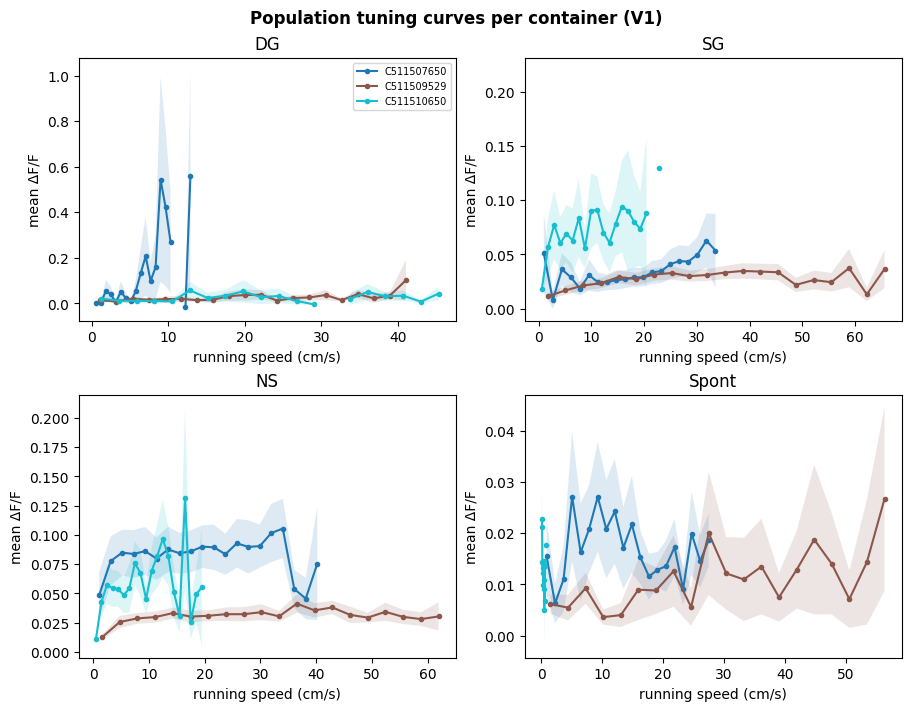

In [57]:
# Population tuning curves — overlay all containers per stimulus (mean ± SEM)
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
axf = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(cids)))

for j, stim in enumerate(STIMULI):
    ax = axf[j]
    for i, (tunings, cid) in enumerate(zip(all_tunings, cids)):
        tu = tunings[stim]
        mr = tu.mean_all_responses  # (n_cells, n_bins)
        m = np.nanmean(mr, axis=0)
        n_valid = np.sum(~np.isnan(mr), axis=0)
        sem = np.nanstd(mr, axis=0, ddof=0) / np.sqrt(n_valid.clip(min=1))
        ax.fill_between(tu.bins_centers, m - sem, m + sem,
                        color=colors[i], alpha=0.15, edgecolor='none')
        ax.plot(tu.bins_centers, m, color=colors[i], label=f'C{cid}',
                marker='o', markersize=3, markerfacecolor=colors[i],
                markeredgecolor=colors[i])
    ax.set_title(stim_to_short(stim))
    ax.set_xlabel('running speed (cm/s)')
    ax.set_ylabel('mean ΔF/F')
    if j == 0:
        ax.legend(fontsize=7)

fig.suptitle('Population tuning curves per container (V1)', fontweight='bold')
plt.savefig("doc/figures/V1/V1_tuning_per_container.png")
plt.show()

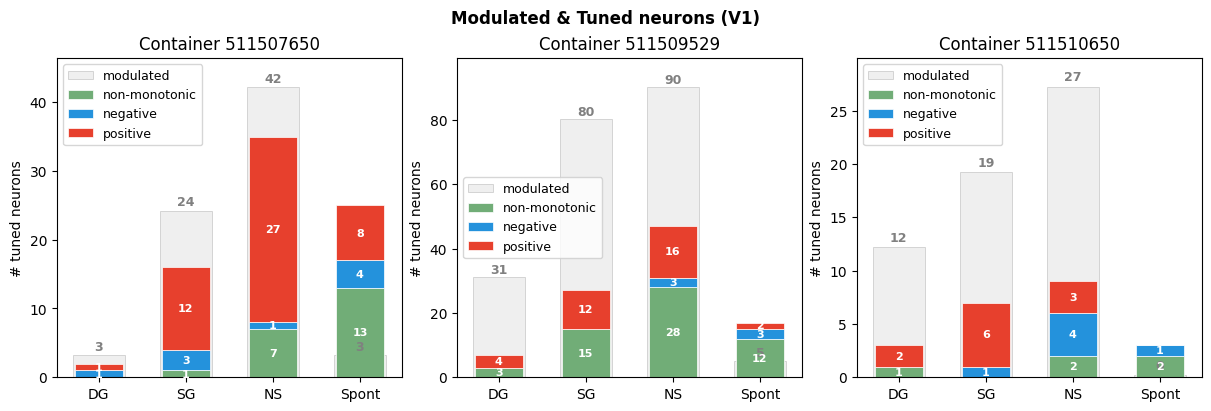

In [58]:
# Monotonicity stacked bar per container
fig, axes = plt.subplots(1, len(cids), figsize=(4*len(cids), 4), constrained_layout=True)
if len(cids) == 1:
    axes = [axes]

for i, (tunings, ax) in enumerate(zip(all_tunings, axes)):
    cont_mod_mask = {stim: all_bm[i][stim].modulated_mask for stim in STIMULI}
    plot_monotonicity_stacked_bar(tunings, modulated_mask=cont_mod_mask, ax=ax)
    ax.set_title(f'Container {cids[i]}')

fig.suptitle('Modulated & Tuned neurons (V1)', fontweight='bold')
plt.savefig("doc/figures/V1/V1_tuned_neurons.png")
plt.show()

## 2.2 Tuning profiles by monotonicity

Groups modulated neurons into: **positive**, **negative**, **non-monotonic** (significant ANOVA but monotonicity p > 0.05), and **non-tuned** (ANOVA p > 0.05). Spontaneous tuning of the same neurons is overlaid.

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:227: RuntimeWarning: Mean of empty slice
  edgecolor='none', label=label)
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


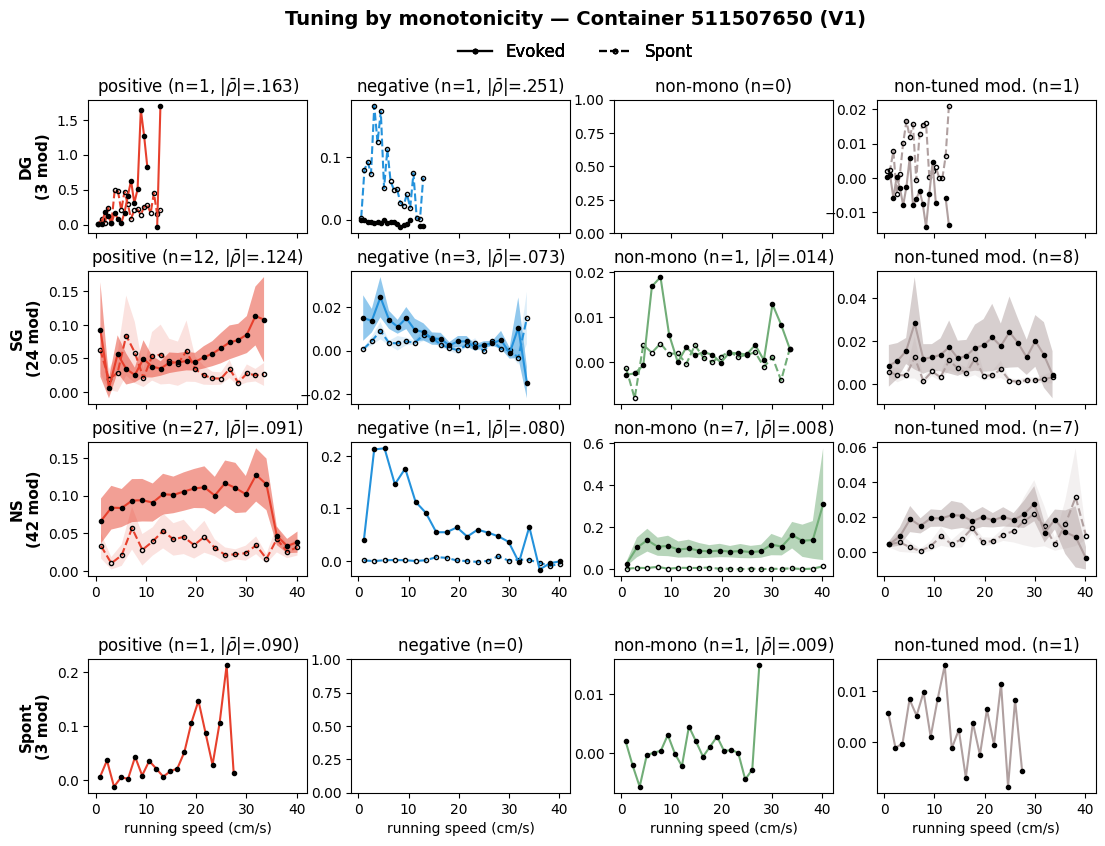

Container 511507650 done.


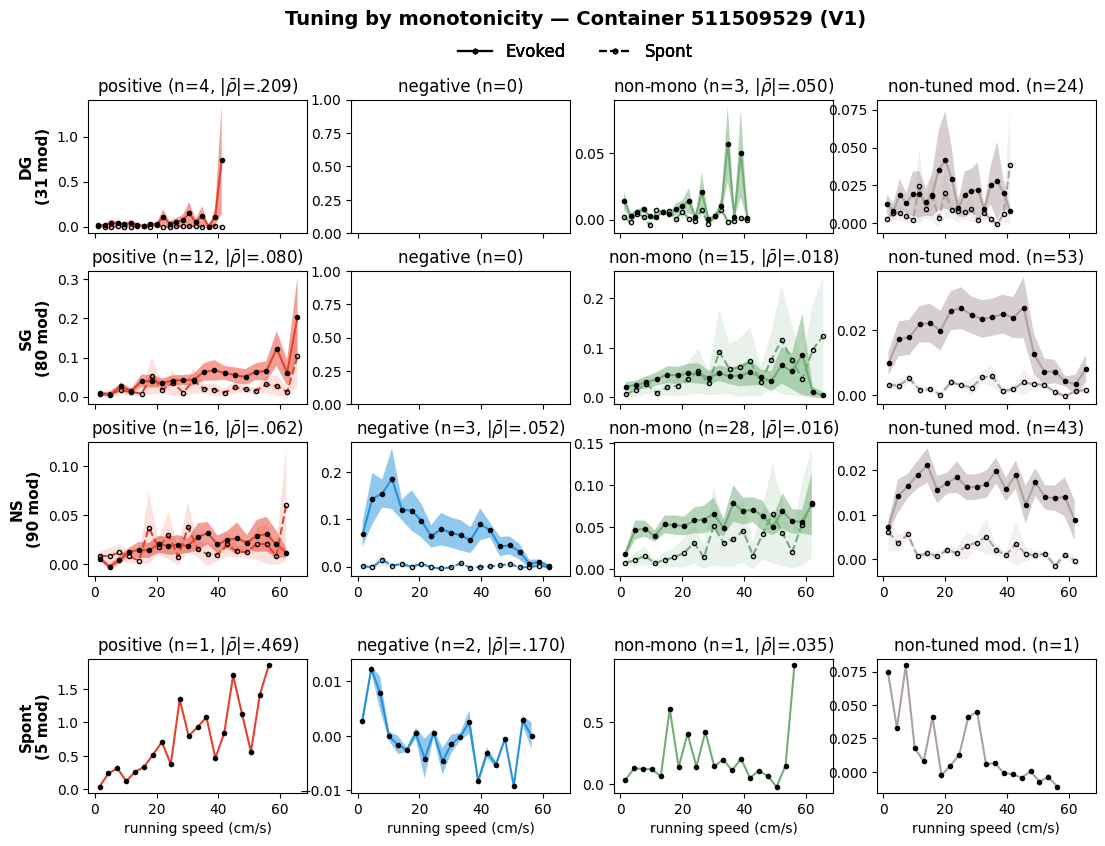

Container 511509529 done.


/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:227: RuntimeWarning: Mean of empty slice
  edgecolor='none', label=label)
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:227: RuntimeWarning: Mean of empty slice
  edgecolor='none', label=label)
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:227: RuntimeWarning: Mean of empty slice
  edgecolor='none', label=label)
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for s

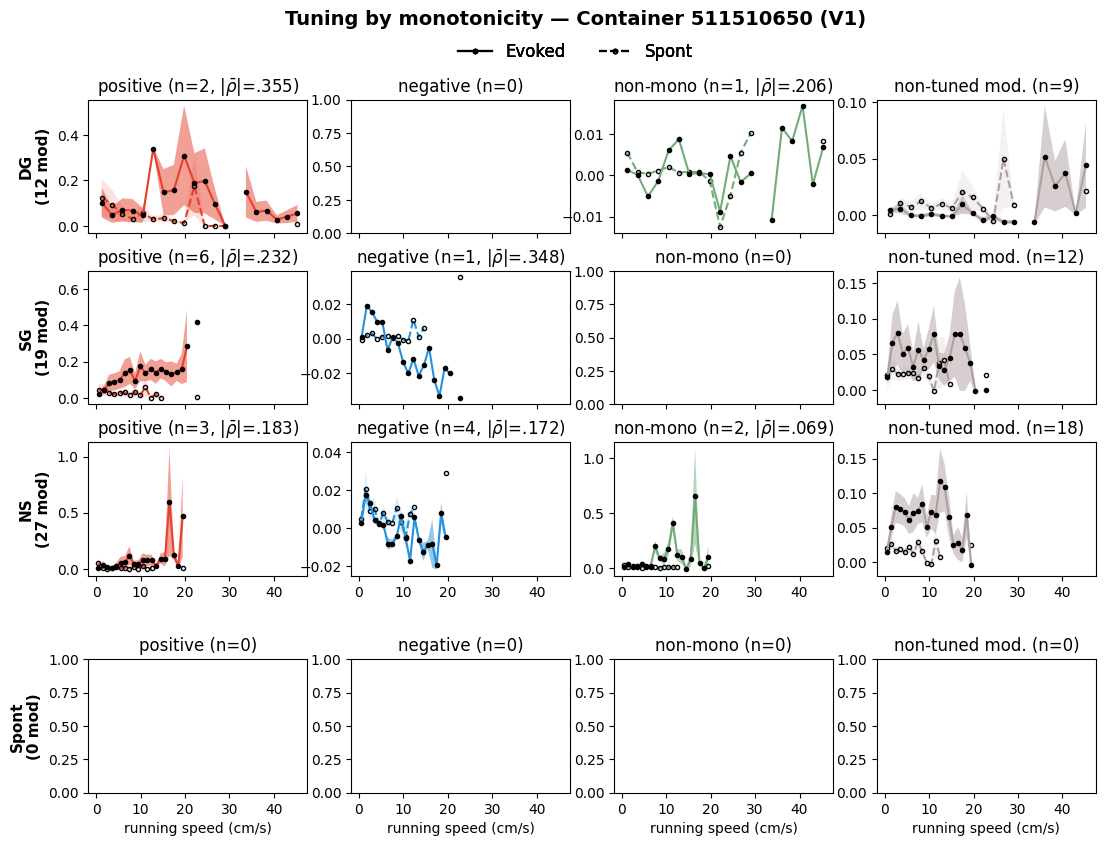

Container 511510650 done.


In [59]:
# Tuning curves grouped by monotonicity — per container
import matplotlib.gridspec as gridspec

for cont_idx, (tunings, cid) in enumerate(zip(all_tunings, cids)):
    cont_mod_mask = {stim: all_bm[cont_idx][stim].modulated_mask for stim in STIMULI}

    fig = plt.figure(figsize=(13, 9))
    gs = gridspec.GridSpec(5, 4, height_ratios=[1, 1, 1, 0.06, 1], hspace=0.35)
    axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(4)]
                      for row in range(5)])
    for ax in axes[3]:
        ax.set_visible(False)

    for row in range(5):
        for col in range(4):
            if row != 3 and (row != 0 or col != 0):
                axes[row, col].sharex(axes[0, 0])
    for col in range(4):
        axes[0, col].tick_params(labelbottom=False)
        axes[1, col].tick_params(labelbottom=False)

    plot_rows = [0, 1, 2, 4]
    for plot_row, stim in zip(plot_rows, STIMULI):
        if stim == 'spontaneous':
            cells = np.where(cont_mod_mask['spontaneous'])[0]
            use_spont = None
        else:
            cells = None
            use_spont = tunings['spontaneous']
        tunings[stim].plot_tuning_by_monotonicity(
            axes=axes[plot_row], spontaneous=use_spont,
            modulated_mask=cont_mod_mask[stim], cells=cells)

        n_mod = int(cont_mod_mask[stim].sum()) if stim != 'spontaneous' else len(cells)
        axes[plot_row, 0].set_ylabel(f"{stim_to_short(stim)}\n({n_mod} mod)",
                                     fontsize=11, fontweight='bold')
        for ax in axes[plot_row]:
            ax.set_xlabel(None)

    for col in range(4):
        axes[4, col].set_xlabel('running speed (cm/s)')
        axes[2, col].tick_params(labelbottom=True)

    fig.suptitle(f'Tuning by monotonicity — Container {cid} (V1)',
                 fontsize=14, fontweight='bold')
    plt.savefig(f"doc/figures/V1/V1_tuning_by_monotonicity_C{cid}.png")
    plt.show()
    print(f"Container {cid} done.")

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:2143: RuntimeWarning: Mean of empty slice
  modulated_any = np.zeros(I, dtype=bool)


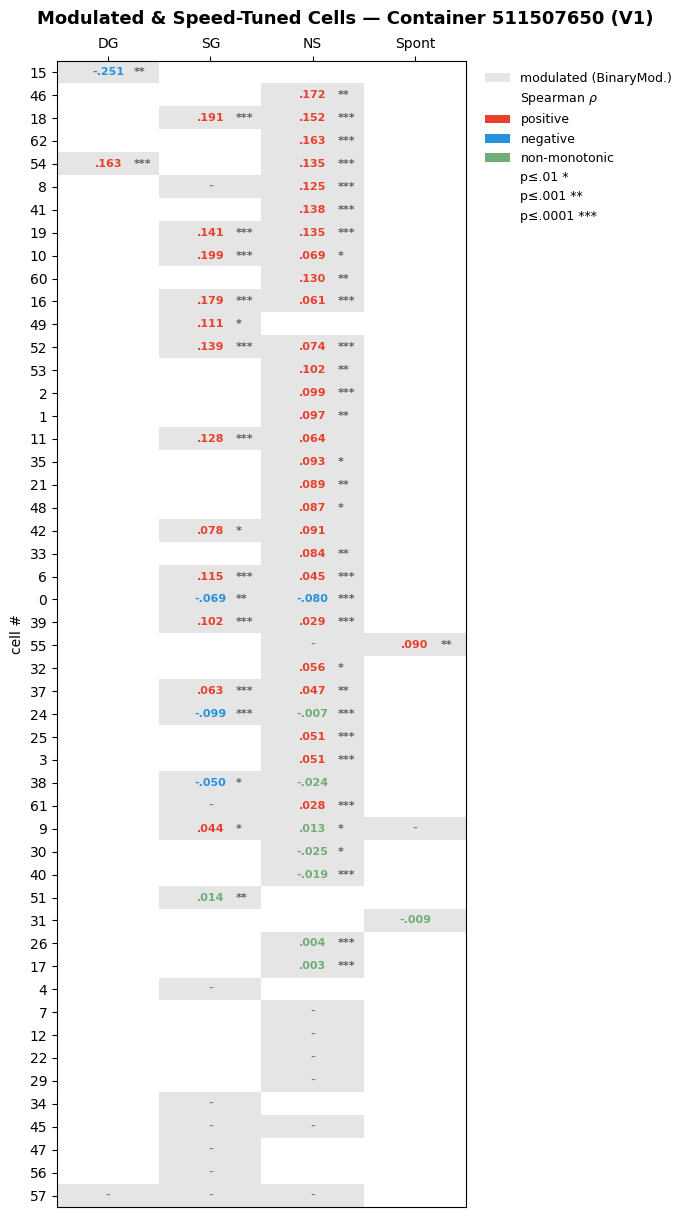

Container 511507650 grid done.


/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:2143: RuntimeWarning: Mean of empty slice
  modulated_any = np.zeros(I, dtype=bool)


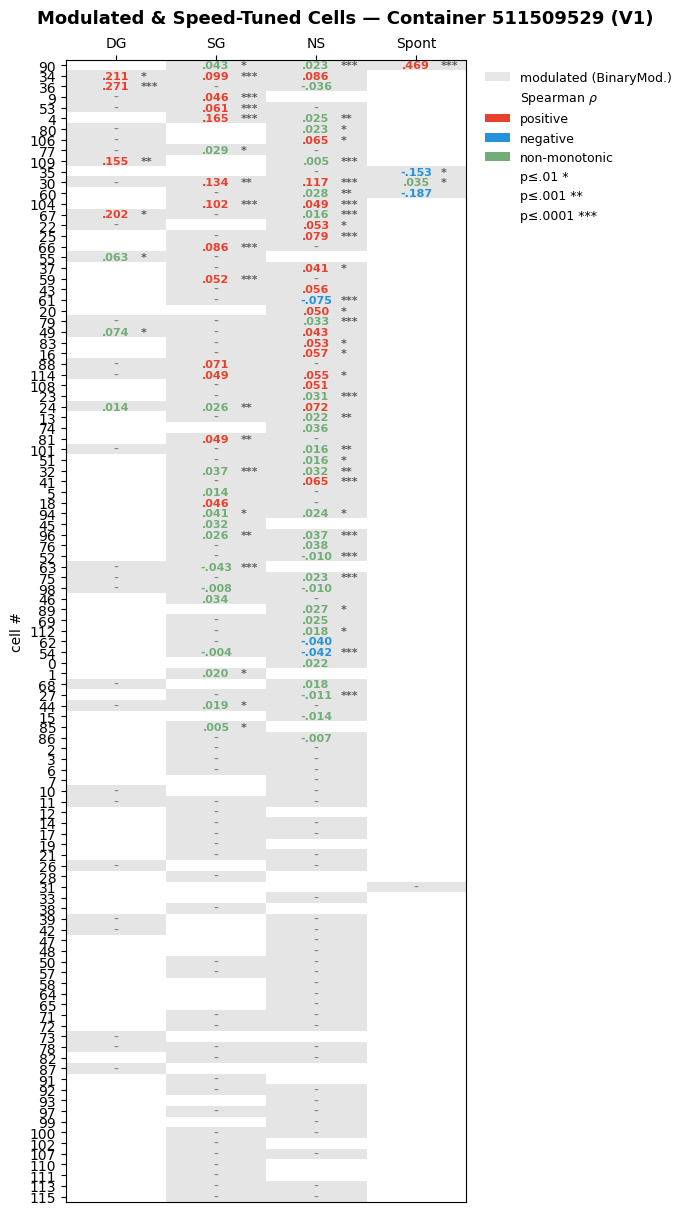

Container 511509529 grid done.


/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:2143: RuntimeWarning: Mean of empty slice
  modulated_any = np.zeros(I, dtype=bool)


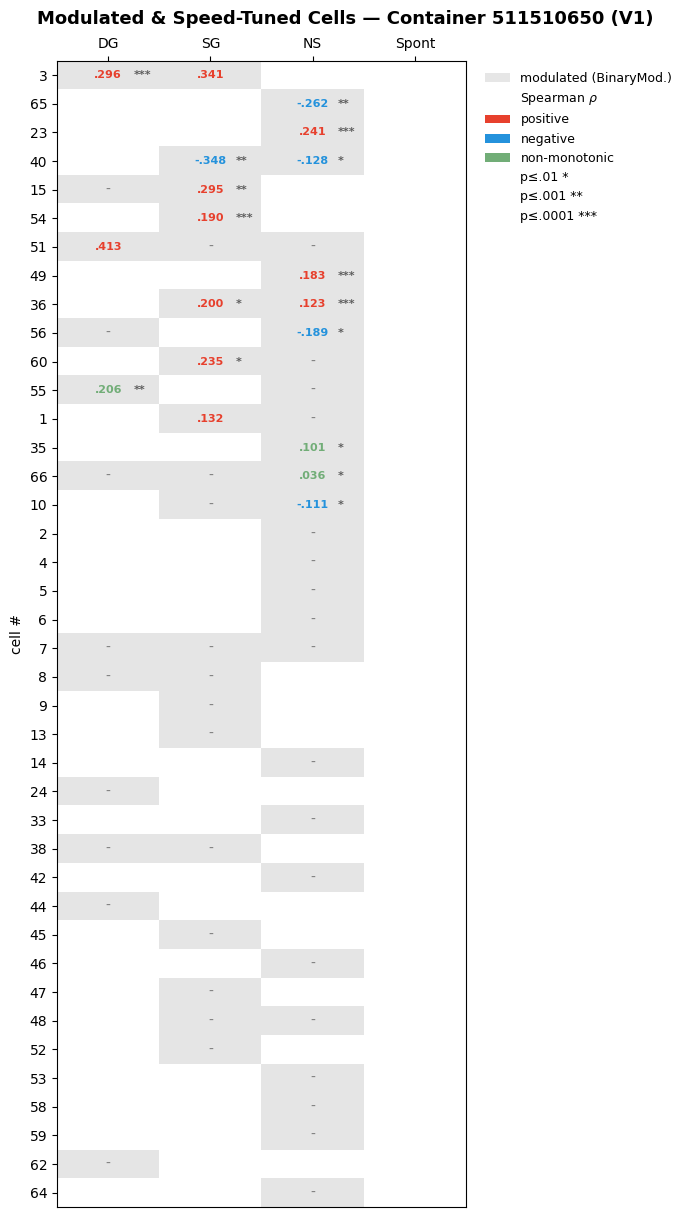

Container 511510650 grid done.


In [60]:
# Per-cell tuning grid map (Spearman rho + ANOVA p-value stars) per container
for cont_idx, (tunings, cid) in enumerate(zip(all_tunings, cids)):
    cont_mod_mask = {stim: all_bm[cont_idx][stim].modulated_mask for stim in STIMULI}
    fig = plot_modulated_tuned_grid(tunings, modulated_mask=cont_mod_mask, figsize=(7, 12))
    fig.suptitle(f'Modulated & Speed-Tuned Cells — Container {cid} (V1)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(f"doc/figures/V1/V1_tuning_profiles_C{cid}.png")
    plt.show()
    print(f"Container {cid} grid done.")